In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f'Tensorflow Version: {tf.__version__}')

Tensorflow Version: 2.15.0


In [19]:
# 데이터 로딩
df = pd.read_csv('pandas/data/mnist_test.csv', header=None)
df.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [20]:
# 전체 데이터 정보 파악
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 59.9 MB


In [21]:
# 결측치 파악
df.isna().sum().sum()

0

In [22]:
# 두번째행의 데이터를 가져와 label/pixel 데이터로 분리
row = df.iloc[1]    # row는 Series 객체가된다.

label = row[0]  # Series 객체 row의 첫번째 데이터는 정답(숫자)이다.
pixels = row[1:].values # 그 이후의 나머지 데이터들은 필셀값들이고, numpy ndarray형식으로 반환

print(f'정답: {label}')
print(f'픽셀 데이터: {pixels}')
print(f'{type(pixels)}')

정답: 2
픽셀 데이터: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0 169 253 253 253 253
 253 253 218  30   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0  52 250 253 210  32
  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  31  18
   0   0   0   0 209 253 253  65   0 

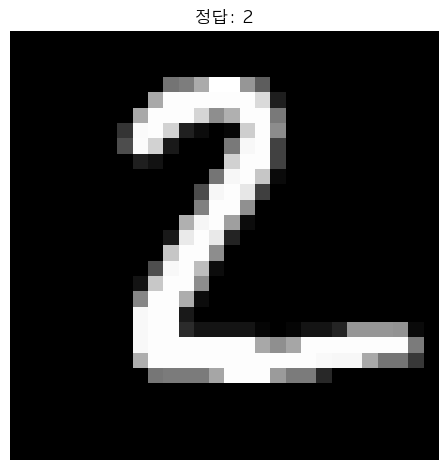

In [23]:
# pixel데이터를 matplotlib로 출력하기

# 1차원 데이터를 2차원 데이터로 변환한다.
image = pixels.reshape(28, 28)

# imshow: 2차원 배열을 이미지(격자 형태의 색)로 그리는 함수
# vmin, vmax: 픽셀값들중 최소, 최대값을 지정
# interpolation: nearest(경계선을 또렷하게 그림), bilinear(blur하게 그림)
plt.imshow(image, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(f'정답: {label}')
plt.axis('off')     # x, y축 감추기
plt.tight_layout()
plt.show()

In [24]:
# 레이블(첫 열)과 픽셀(나머지 784열) 분리
y = df.iloc[:, 0].values    # 전체행에서 0번 인덱스 컬럼의 데이터를 분리, 정답
X = df.iloc[:, 1:].values   # 나머지 픽셀 데이터 분리

# 스케일링
X = X.astype(int) / 255.0

# Conv2D의 입력 형태로 변환: (10000, 784) -> (10000, 28, 28, 1)
# 10000: 데이터 개수(행)
# 28 x 28: Height x Width
# 1: 채널수(흑백), 컬러채널(RGB)형태이면 3
X = X.reshape(-1, 28, 28, 1)    # -1은 내가 비워둔 자리 -> 저 자리는 numpy가 알아서 채워라 라는 의미

print(X.shape, y.shape) 


(10000, 28, 28, 1) (10000,)


In [25]:
# 학습/검증 데이터로 분리(8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 검증 데이터 비율 20%
    random_state=42,    # 재현성(같은 분할 보장)
    stratify=y          # 0 ~ 9 비율을 train/test에 동일한 비율로 
)

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),    # batch size는 학습할때 결정됨, 이미지 한장의 형태만 알려줌
    
    # 합성곱 블록1 - 특징 추출
    
    # 32: filters, 필터의 개수=뽑을 특징의 종류 -> 출력채널이 32
    # kernel_size=3, 필터 크기를 3x3, 한번에 3x3 픽셀 영역을 보고 특징 계산, 보통 3을 씀
    # 활성화 함수: relu -> max(0, x), CNN 표준
    # padding: filter를 이미지에 대면 테두리가 깎여서 크기가 줄어드는데 이를 방지, 가장자리에 0을 덧대 출력 크기를 입력돠 동일하게 유지
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    
    # 크기를 절반으로 줄임: 2x2 영역에 가장 큰 값 하나만 남김, 28x28 -> 14x14
    layers.MaxPooling2D(pool_size=2),
    
    # 합성곱 블록2
    # 왜 필터를 32 → 64로 늘리나: 초반 층은 단순한 특징(선, 모서리)을 적은 종류로 잡고, 
    # 뒤로 갈수록 그 조합인 복잡한 특징(곡선, 숫자 일부 모양)을 더 많은 종류로 잡는다. 
    # 그래서 가로·세로가 줄어드는 만큼 채널을 늘려 표현력을 유지하는 게 CNN의 전형적 패턴. 
    # 32 → 64 → 128처럼 2배씩 늘리는 게 관례
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    
    # 분류기
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

## loss의 종류

|유형|loss|

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10


2026-07-02 03:19:22.442290: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


63/63 [==============================] - 5s 31ms/step - loss: 0.9394 - accuracy: 0.6926 - val_loss: 0.2576 - val_accuracy: 0.9245
Epoch 2/10
63/63 [==============================] - 1s 18ms/step - loss: 0.2727 - accuracy: 0.9137 - val_loss: 0.1659 - val_accuracy: 0.9505
Epoch 3/10
63/63 [==============================] - 1s 18ms/step - loss: 0.1674 - accuracy: 0.9490 - val_loss: 0.1103 - val_accuracy: 0.9625
Epoch 4/10
63/63 [==============================] - 1s 18ms/step - loss: 0.1540 - accuracy: 0.9521 - val_loss: 0.1045 - val_accuracy: 0.9660
Epoch 5/10
63/63 [==============================] - 1s 17ms/step - loss: 0.1231 - accuracy: 0.9649 - val_loss: 0.0862 - val_accuracy: 0.9760
Epoch 6/10
63/63 [==============================] - 1s 18ms/step - loss: 0.1050 - accuracy: 0.9693 - val_loss: 0.0878 - val_accuracy: 0.9705
Epoch 7/10
63/63 [==============================] - 1s 19ms/step - loss: 0.0864 - accuracy: 0.9744 - val_loss: 0.1044 - val_accuracy: 0.9715
Epoch 8/10
63/63 [======

In [29]:
val_loss, val_acc = model.evaluate(X_test, y_test, verbose=1)
print(f'검증 정확도: {val_acc:.4f}')

63/63 [==============================] - 1s 10ms/step - loss: 0.0914 - accuracy: 0.9745
검증 정확도: 0.9745


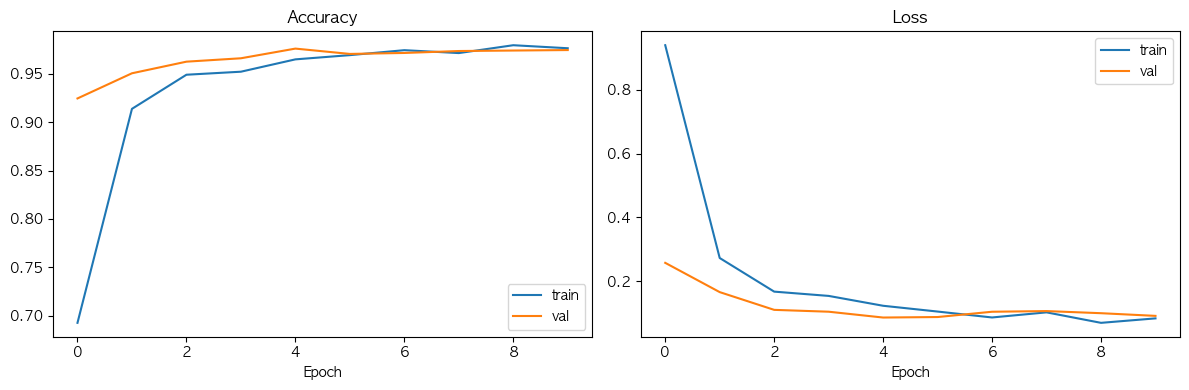

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


1/1 [==============================] - 1s 927ms/step


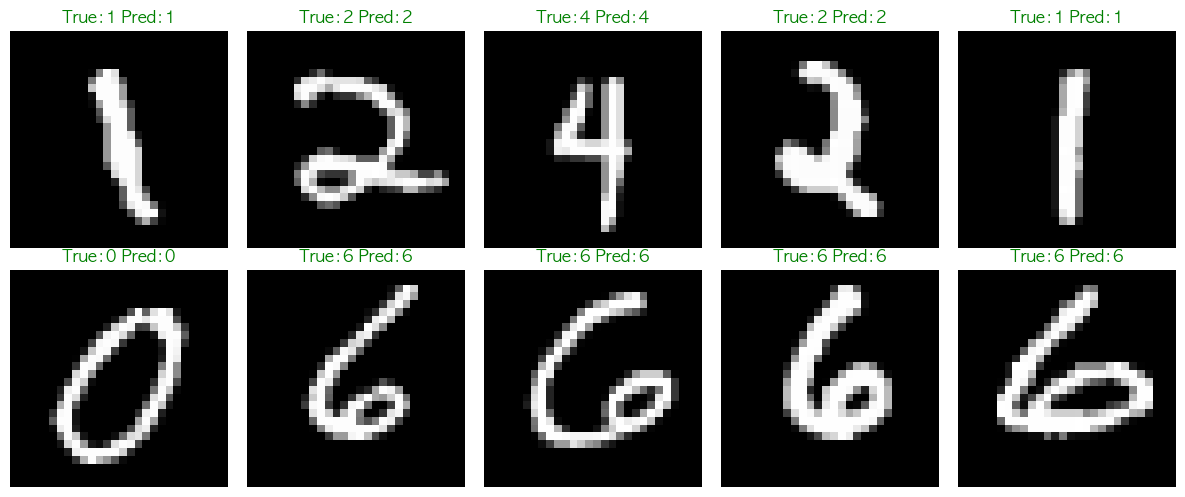

In [31]:
# 검증셋에서 예측
pred_probs = model.predict(X_test[:10])     # (10, 10) 각 숫자일 확률
pred_labels = np.argmax(pred_probs, axis=1) # 가장 높은 확률의 인덱스 = 예측 숫자

# 실제 vs 예측 비교 출력
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    true = y_test[i]
    pred = pred_labels[i]
    color = 'green' if true == pred else 'red'   # 맞으면 초록, 틀리면 빨강
    plt.title(f'True:{true} Pred:{pred}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()